# Financial news headlines 

## Overview

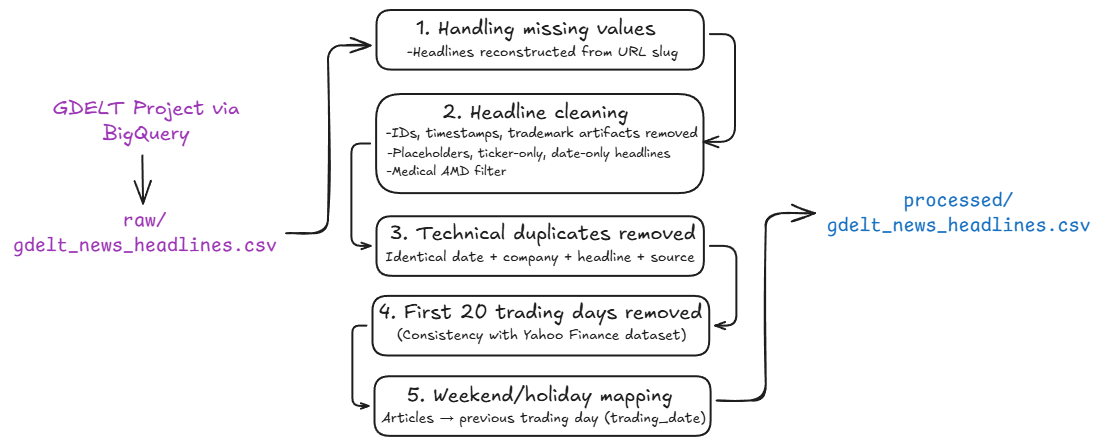

The dataset was collected from the GDELT Project (`gdeltv2.gkg_partitioned` table) 
using the following BigQuery query. Articles were filtered to eleven financial news 
sources covering the period 2016–2026, and matched to NVDA, AMD, and INTC using 
organization-level entity recognition from GDELT's V2Organizations field.

```sql
WITH base AS (
  SELECT
    DATE(_PARTITIONTIME) AS date,
    SourceCommonName AS source,

    COALESCE(
      REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)<\/PAGE_TITLE>'),
      REGEXP_REPLACE(
        REGEXP_REPLACE(
          REGEXP_EXTRACT(DocumentIdentifier, r'/([^/?#]+)(?:[?#].*)?$'),
          r'[-_]+',
          ' '
        ),
        r'\.[a-z]+$',
        ''
      )
    ) AS headline,

    DocumentIdentifier AS url,
    V2Organizations
  FROM `gdelt-bq.gdeltv2.gkg_partitioned`
  WHERE
    _PARTITIONTIME BETWEEN TIMESTAMP('2016-03-31')
    AND TIMESTAMP('2026-03-31')

    AND SourceCommonName IN (
      'reuters.com',
      'cnbc.com',
      'marketwatch.com',
      'bloomberg.com',
      'wsj.com',
      'ft.com',
      'finance.yahoo.com',
      'seekingalpha.com',
      'investing.com',
      'morningstar.com',
      'nasdaq.com'
    )
),

matched AS (
  SELECT date, source, headline, url, 'NVDA' AS company
  FROM base
  WHERE
    REGEXP_CONTAINS(LOWER(V2Organizations), r'(^|[^a-z0-9])(nvidia|nvda|nvidia corporation|nvidia corp)([^a-z0-9]|$)')
    OR REGEXP_CONTAINS(LOWER(url), r'(^|[^a-z0-9])(nvidia|nvda)([^a-z0-9]|$)')

  UNION ALL

  SELECT date, source, headline, url, 'AMD' AS company
  FROM base
  WHERE
    REGEXP_CONTAINS(LOWER(V2Organizations), r'(^|[^a-z0-9])(amd|advanced micro devices|advanced micro devices inc|advanced micro devices corporation)([^a-z0-9]|$)')
    OR REGEXP_CONTAINS(LOWER(url), r'(^|[^a-z0-9])(amd|advanced-micro-devices|advanced-micro)([^a-z0-9]|$)')

  UNION ALL

  SELECT date, source, headline, url, 'INTC' AS company
  FROM base
  WHERE
    REGEXP_CONTAINS(LOWER(V2Organizations), r'(^|[^a-z0-9])(intel|intel corp|intel corporation|intc)([^a-z0-9]|$)')
    OR REGEXP_CONTAINS(LOWER(url), r'(^|[^a-z0-9])(intel|intc)([^a-z0-9]|$)')
)

SELECT DISTINCT
  date,
  source,
  headline,
  company,
  url
FROM matched
WHERE headline IS NOT NULL
ORDER BY date, company;


```

## 1. Configuration

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import mlflow
import re
from datetime import timedelta
warnings.filterwarnings('ignore')

START_DATE = '2016-03-31'
END_DATE   = '2026-03-31'
COMPANIES  = ['NVDA', 'AMD', 'INTC']

INPUT_PATH  = 'datasets/raw/gdelt_news_headlines.csv'
OUTPUT_PATH = 'datasets/processed/gdelt_news_headlines.csv'

df = pd.read_csv(INPUT_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f'Loaded shape : {df.shape}')
print(f'Columns      : {df.columns.tolist()}')

Loaded shape : (79013, 5)
Columns      : ['date', 'source', 'headline', 'company', 'url']


In [200]:
df.head()

,date,source,headline,company,url
0,2016-03-31,nasdaq.com,heres why amd is a zacks rank 5 strong sell st...,AMD,http://www.nasdaq.com/article/heres-why-amd-is...
1,2016-03-31,seekingalpha.com,3962165 vuzixs vuzi ceo paul travers q4 2015 r...,INTC,http://seekingalpha.com/article/3962165-vuzixs...
2,2016-03-31,marketwatch.com,alpine security offers cybersec first responde...,INTC,http://www.marketwatch.com/story/alpine-securi...
3,2016-03-31,seekingalpha.com,3962150 par technologys par ceo karen sammon q...,INTC,http://seekingalpha.com/article/3962150-par-te...
4,2016-03-31,seekingalpha.com,3962297 excellence rewarded avago,INTC,http://seekingalpha.com/article/3962297-excell...


## 2. Handling missing values

In [201]:
df.isna().sum()

date         0
source       0
headline    15
company      0
url          0
dtype: int64

In [202]:
df[df["headline"].isna()]["url"].iloc[0]

'https://www.marketwatch.com/articles/intel-director-henry-buys-1-million-of-stock-51581722659'

In [203]:
df[df["headline"].isna()]["url"].iloc[1]

'https://www.marketwatch.com/story/intel-stock-rallies-after-upgrade-says-chip-maker-is-starting-to-executeon-a-coherent-strategy-11641405507'

Missing values detected in the `headline` column were replaced using information extracted from the corresponding article URLs. Since only 15 records contained missing headlines, and the URLs themselves clearly contained the article titles in slug format, the missing values were reconstructed by parsing the final segment of the URL, removing numeric identifiers, and replacing hyphens with spaces

In [204]:
def extract_headline_from_url(url):
    slug = url.split("/")[-1]

    slug = re.sub(r'-\d+$', '', slug)

    slug = slug.replace("-", " ")

    return slug.strip()

mask = df["headline"].isna()

df.loc[mask, "headline"] = ( df.loc[mask, "url"].apply(extract_headline_from_url))

In [205]:
df.isna().sum().sum()

np.int64(0)

## 3. Headline quality

In [206]:
# Medical keywords related to Age-related Macular Degeneration (AMD)
# used to exclude non-company-related AMD articles
AMD_MEDICAL_KEYWORDS = [
    'macular', 'degeneration', 'retinal', 'ophthalm',
    'clinical trial', 'patient', 'wet amd', 'dry amd',
    'micro needling', 'thermi', 'arvo', 'brightfocus',
    'choroid', 'opt-302', 'opt 302'
]

# Headlines considered artifacts/noise and removed from the dataset
ARTIFACT_PATTERNS = [
    r'^story$',                    # Bloomberg generic placeholder
    r'^article$',                  # Morningstar generic placeholder
    r'^press releases$',           # Nasdaq generic category
    r'^(INTC|NVDA|AMD)$',          # ticker only
    r'^id[A-Z]{2}[A-Z0-9]+$',      # Reuters IDs, e.g. idUSKCN0X...
    r'^[A-Z0-9]{8}-[a-z0-9-]+$',   # FT.com hash identifiers
    r'^\d{10}$',                   # Unix timestamp
    r'^[A-Za-z0-9+/=]+=',          # Base64 artifacts
    r'referer=',                   # URL parameters
    r'classification=',
    r'^\w+ \d{1,2} \d{4}$',        # "May 14 2018", "October 6 2017"
    r'^\d{4}-\d{2}-\d{2}$',        # ISO date
]

In [207]:
def is_artifact(text):
    """
    Detects noisy or meaningless headlines.
    """
    if pd.isna(text) or text is None:
        return True

    text = text.strip()

    # Remove very short headlines
    if len(text.split()) < 3:
        return True

    # Match known artifact patterns
    for pattern in ARTIFACT_PATTERNS:
        if re.match(pattern, text, re.IGNORECASE):
            return True

    return False

In [208]:
def is_medical_amd(row):
    """
    Filters medical AMD articles unrelated to AMD company.
    """
    if row['company'] != 'AMD':
        return False

    headline_lower = str(row['headline']).lower()

    return any(keyword in headline_lower for keyword in AMD_MEDICAL_KEYWORDS)

In [209]:
def clean_headline(text):
    """
    Cleans extracted headlines by removing common scraping artifacts,
    IDs, timestamps, URL parameters, and formatting noise.
    """
    if pd.isna(text) or text is None:
        return None

    # Remove registered trademark extraction artifact (e.g. intelr -> intel)
    text = re.sub(r'\b(intel|xeon|core|thunderbolt|realsense)(r|tm)\b', r'\1', text, flags=re.IGNORECASE)

    # Remove Nasdaq IDs (cm + digits)
    text = re.sub(r'\bcm\d+\b', '', text)

    # Remove Reuters article IDs, e.g. idINKCN0XO2LY, idUSKCN...
    text = re.sub(r'\bid[A-Z]{2}[A-Z0-9]+\b', '', text, flags=re.IGNORECASE)

    # Remove SeekingAlpha ID at the beginning
    text = re.sub(r'^\d{7}\s+', '', text) 

    # Remove dates in YYYYMMDD or YYYYMMDD XXXXX format
    text = re.sub(r'\b\d{8}(\s+\d{3,6})?\b', '', text)

    # Remove dates in YYYY MM DD format
    text = re.sub(r'\b\d{4}\s+\d{2}\s+\d{2}\b', '', text)

    # Remove Unix timestamps
    text = re.sub(r'\b\d{9,11}\b', '', text)

    # Remove trailing WSJ/FT numeric identifiers
    text = re.sub(r'\s+\d{9,10}$', '', text.rstrip())

    # Remove URL query artifacts
    text = re.sub(r'&[a-z_]+=\S+', '', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove "2nd update", "update", "1st update" artefacts
    text = re.sub(r'\b\d*(st|nd|rd|th)?\s*update\b', '', text, flags=re.IGNORECASE)

    return text if text else None

In [210]:
# Apply headline cleaning
df['headline'] = df['headline'].apply(clean_headline)

# Remove artifact headlines
df = df[~df['headline'].apply(is_artifact)]

# Remove medical AMD articles
df = df[~df.apply(is_medical_amd, axis=1)]

print(f'Remaining rows: {len(df)}')

Remaining rows: 74920


In [211]:
# Headline length distribution
df['headline_len'] = df['headline'].str.len()

print('Headline length stats:')
print(df['headline_len'].describe())

print(f'\nHeadlines under 10 chars : {(df["headline_len"] < 10).sum()}')
print(f'Headlines over 300 chars : {(df["headline_len"] > 300).sum()}')

# Show suspiciously short headlines
print('\nShortest headlines:')
print(df.nsmallest(5, 'headline_len')[['date', 'company', 'headline']].to_string())

Headline length stats:
count    74920.000000
mean        66.848959
std         25.422407
min          7.000000
25%         53.000000
50%         64.000000
75%         78.000000
max        587.000000
Name: headline_len, dtype: float64

Headlines under 10 chars : 51
Headlines over 300 chars : 34

Shortest headlines:
            date company   headline
16372 2017-08-30    INTC    at t 5g
644   2016-04-22    INTC  ny stx us
673   2016-04-23    INTC  ny stx us
2833  2016-07-21    INTC  ny stx us
2851  2016-07-21    INTC  ny stx us


## 4. Handling duplicate headlines

### Technical duplicates 
These are rows where `date`, `company`, `headline` AND `source` are all identical —
a data artifact from GDELT's collection pipeline where the same article 
was recorded multiple times. These carry no additional information and are removed.

In [212]:
df[df.duplicated( subset=['date', 'company', 'headline', 'source'], keep=False)].head()

,date,source,headline,company,url,headline_len
15,2016-03-31,nasdaq.com,john doerr to become kleiner perkinss first ch...,INTC,http://www.nasdaq.com/article/john-doerr-to-be...,52
17,2016-03-31,nasdaq.com,john doerr to become kleiner perkinss first ch...,INTC,http://www.nasdaq.com/article/john-doerr-to-be...,52
77,2016-04-04,nasdaq.com,intel ceos pay up 31 in 2015,INTC,http://www.nasdaq.com/article/intel-ceos-pay-u...,28
78,2016-04-04,nasdaq.com,intel ceos pay up 31 in 2015,INTC,http://www.nasdaq.com/article/intel-ceos-pay-u...,28
368,2016-04-19,reuters.com,us intel results,INTC,http://www.reuters.com/article/us-intel-result...,16


In [213]:
before = len(df)
df = df.drop_duplicates(subset=['date', 'company', 'headline', 'source'], keep='first')
print(f'Dropped {before - len(df)} technical duplicates (identical date/company/headline/source)')

Dropped 6523 technical duplicates (identical date/company/headline/source)


### Syndicated news articles
Syndicated articles are the same news story published across multiple sources on the same day.
These are **intentionally kept** in the dataset because repeated coverage across different media outlets reflects the overall intensity of public and market attention surrounding a particular event. For example, when a major event such as Intel layoffs is covered simultaneously by Reuters, Bloomberg, CNBC, and MarketWatch, the number of publications itself becomes a meaningful signal that can later be incorporated through features such as `news_count`.

When aggregating sentiment using **mean**, syndicated duplicates do not distort 
the sentiment score — identical headlines produce identical scores, 
leaving the mean unchanged. This gives us the best of both worlds:
- Clean sentiment signal (mean is unaffected)
- Accurate media intensity signal (news_count reflects true coverage)

In [214]:
# Example - AMD China deal
mask = (df['date'] == '2016-04-21') & \
       (df['company'] == 'AMD') & \
       (df['headline'].str.contains('china', na=False))

df[mask][['date', 'company', 'source', 'headline']]

,date,company,source,headline
536,2016-04-21,AMD,nasdaq.com,amd to license chip technology to china chip v...
542,2016-04-21,AMD,wsj.com,amd to license chip technology to china chip v...
544,2016-04-21,AMD,bloomberg.com,amd to license server chip technology for use ...


### Multi-Company headlines

Some headlines mention more than one tracked company simultaneously (e.g. AMD and Intel in the same article). Since the dataset is intended for daily sentiment aggregation on a per-company basis, these records were intentionally retained for each relevant company.

For example, a headline discussing competition between AMD and Intel is considered informative for both companies and therefore appears once under `AMD` and once under `INTC`. This behavior is expected and aligns with the later aggregation process, where sentiment and news volume are calculated separately for each company and each trading day.

In [215]:
def count_company_mentions(headline: str) -> int:
    h = str(headline).lower()

    patterns = {
        'NVDA': r'(^|[^a-z0-9])(nvidia|nvda)([^a-z0-9]|$)',
        'AMD': r'(^|[^a-z0-9])(amd|advanced micro devices)([^a-z0-9]|$)',
        'INTC': r'(^|[^a-z0-9])(intel|intc)([^a-z0-9]|$)',
    }

    count = 0

    for pattern in patterns.values():
        if re.search(pattern, h):
            count += 1

    return count

In [216]:
df['mention_count'] = df['headline'].apply(count_company_mentions)

multi_company = df[df['mention_count'] > 1]

print(f'Headlines mentioning multiple companies: {len(multi_company)} ({100 * len(multi_company) / len(df):.2f}%)')

print('\nSample multi-company headlines:')
multi_company[['date', 'company', 'headline']].head(10)

Headlines mentioning multiple companies: 2576 (3.77%)

Sample multi-company headlines:


,date,company,headline
119,2016-04-06,AMD,nvidia drops pascal bomb amd
145,2016-04-06,NVDA,nvidia drops pascal bomb amd
156,2016-04-07,INTC,nvidia corp announces answer to intel corps xe...
168,2016-04-07,NVDA,nvidia corp announces answer to intel corps xe...
269,2016-04-14,AMD,amd bombs nvidia
274,2016-04-14,INTC,amd bombs nvidia
282,2016-04-14,NVDA,amd bombs nvidia
437,2016-04-20,INTC,what intel corps earnings results mean for nvi...
520,2016-04-20,NVDA,what intel corps earnings results mean for nvi...
727,2016-04-26,AMD,the zacks analyst blog highlights intel advanc...


## 5. News coverage analysis

Weekend and holiday articles are mapped to the **previous** trading day, 
reflecting the assumption that news published on Saturday or Sunday 
represents information that accumulated after Friday's close. 
This weekend sentiment is therefore attributed to Friday and subsequently 
influences Monday's trading session.

In [ ]:
technical_df = pd.read_csv('datasets/processed/yahoo_finance.csv')
technical_df['date'] = pd.to_datetime(technical_df['date'])

# Set of unique trading days
trading_days_set = set(technical_df['date'].dt.date.unique())
trading_days = len(trading_days_set)

# Filter news to only dates >= first trading day (in past we remove first 20 rows because of calculation for tehnical analysis)
first_trading_day = min(trading_days_set)
before = len(df)
df = df[df['date'].dt.date >= first_trading_day]
print(f'Dropped {before - len(df)} articles before first trading day ({first_trading_day})')
print(f'Total trading days: {trading_days}')


Dropped 668 articles before first trading day (2016-04-28)
Total trading days: 2493


In [218]:
def map_to_previous_trading_day(date):
    d = date.date()
    min_date = min(trading_days_set)
    
    if d < min_date:
        return pd.NaT
    
    count = 0
    while d not in trading_days_set:
        d -= timedelta(days=1)  # ← idemo unazad
        count += 1
        if count > 10 or d < min_date:
            return pd.NaT
    
    return pd.Timestamp(d)

df['trading_date'] = df['date'].apply(map_to_previous_trading_day)

In [ ]:
print(f'\nTotal trading days: {trading_days}')
print('\nDays with at least one article per company:')
for company in ['NVDA', 'AMD', 'INTC']:
    days_covered = df[df['company'] == company]['trading_date'].nunique()
    pct = days_covered / trading_days * 100
    print(f'  {company}: {days_covered} days covered ({pct:.1f}% of trading days)')


Total NYSE trading days: 2493

Days with at least one article per company:
  NVDA: 2397 days covered (96.1% of trading days)
  AMD: 1791 days covered (71.8% of trading days)
  INTC: 2371 days covered (95.1% of trading days)


**Handling of missing news on trading days** will be addressed in the final dataset 
construction phase. Following Audrino, Sigrist, & Ballinari (2020), who 
impute missing sentiment values with neutral scores, days without news 
coverage will be assigned a sentiment value of 0, under the assumption 
that the absence of news carries no directional signal. Additionally, 
`news_count`, the number of articles per company per trading day, is 
retained as a separate feature, as media attention intensity itself 
may carry predictive signal independent of sentiment direction.

In [220]:
company_colors = {"NVDA": "#99d8c9", "AMD": "#c994c7", "INTC": "#e7e1ef"}
sns.set_theme(style="ticks", font_scale=1.1)

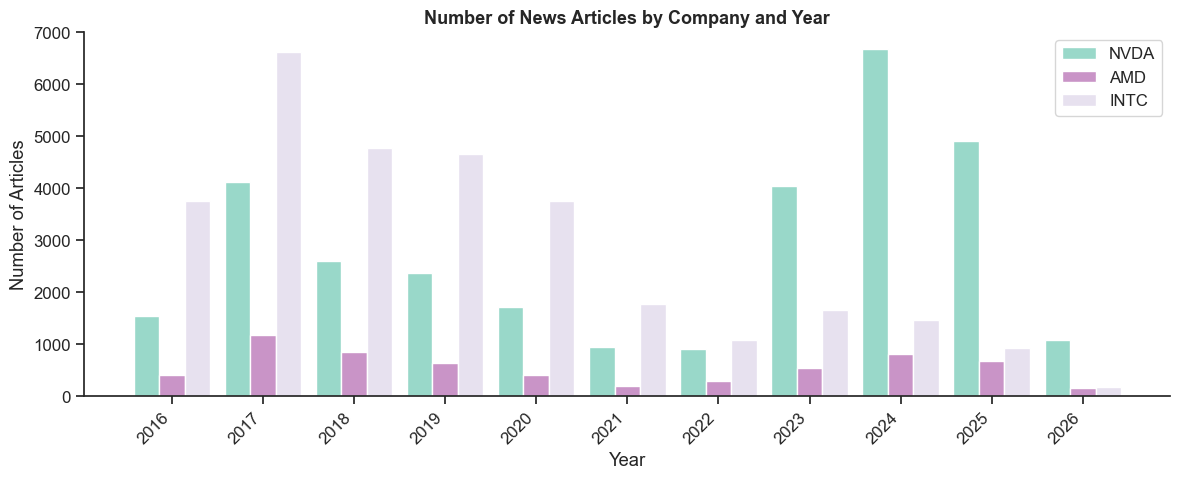

In [221]:
df["year"] = df["trading_date"].dt.year

fig, ax = plt.subplots(figsize=(12, 5))

yearly = (df.groupby(["year", "company"])
            .size()
            .reset_index(name="count"))

x = sorted(yearly["year"].astype(int).unique())
x_idx = range(len(x))
bar_width = 0.28
offsets = {"NVDA": -bar_width, "AMD": 0, "INTC": bar_width}

for company, color in company_colors.items():
    data = yearly[yearly["company"] == company].set_index("year").reindex(x, fill_value=0)
    positions = [i + offsets[company] for i in x_idx]
    ax.bar(positions, data["count"], width=bar_width,
           label=company, color=color, edgecolor="white")

ax.set_title("Number of News Articles by Company and Year",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Articles")
ax.set_xlabel("Year")
ax.set_xticks(list(x_idx))
ax.set_xticklabels(x, rotation=45, ha="right")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

The distribution of news articles varies significantly across companies and years. Intel (INTC) dominates the earlier years of the dataset, particularly between 2016 and 2020, while NVIDIA (NVDA) experiences a substantial increase in media coverage starting from 2023, coinciding with the rapid growth of AI-related market interest. AMD consistently receives fewer articles compared to NVDA and INTC throughout the observed period. It should also be noted that the year 2026 is still ongoing, which explains the lower number of collected articles for that year, and also we didn't collect first couple month of 2016.


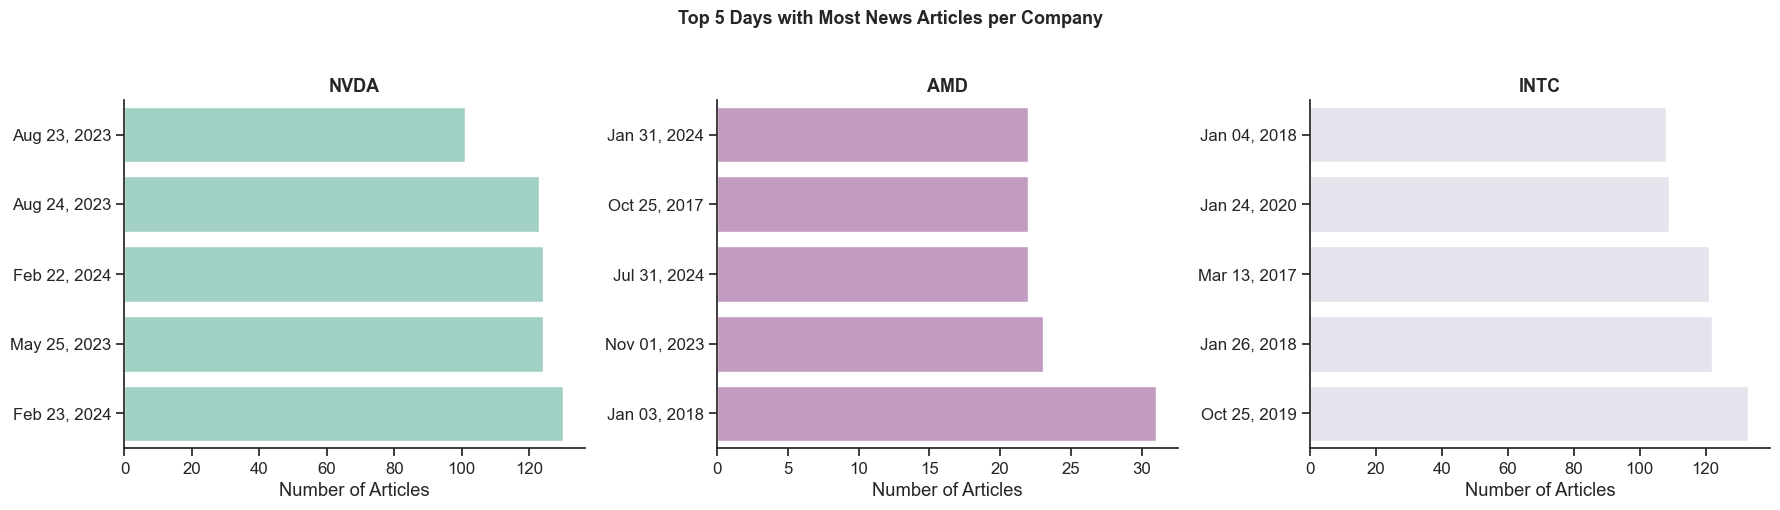

In [222]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (company, color) in zip(axes, company_colors.items()):
    top5 = (df[df["company"] == company]
              .groupby("trading_date")
              .size()
              .nlargest(5)
              .reset_index(name="count")
              .sort_values("count"))

    top5["label"] = top5["trading_date"].dt.strftime("%b %d, %Y")

    sns.barplot(data=top5, x="count", y="label", ax=ax,
                color=color, orient="h")

    ax.set_title(company, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Articles")
    ax.set_ylabel("")
    sns.despine(ax=ax)

fig.suptitle("Top 5 Days with Most News Articles per Company",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The peaks in daily news coverage correspond to major company-specific events and periods of heightened market attention. 

For NVIDIA (NVDA), the largest spikes in May 2023 and February 2024 are associated with the company’s exceptionally strong AI-driven earnings reports and rapidly increasing demand for H100 GPUs following the expansion of generative AI technologies.

For AMD, the highest coverage days in 2017–2018 largely coincide with earnings announcements, product launches, and intensified competition within the CPU and GPU markets, particularly surrounding the Ryzen and EPYC product lines.

For Intel (INTC), the largest spikes during 2017–2019 are related to major semiconductor industry developments, including earnings reports, leadership changes, security vulnerabilities such as Spectre and Meltdown, and broader restructuring activities within the company.

## 6. Final dataset

At this stage, the dataset has undergone the following preprocessing steps:
- **First 20 trading days removed** to ensure consistency with the Yahoo Finance 
  dataset, where technical indicators could not be computed for the initial observations
- **Missing headline values** reconstructed from article URLs where possible
- **Headline cleaning** — removal of artifacts, IDs, timestamps, medical AMD articles, 
  and other noise
- **Technical duplicates** removed (identical date, company, headline, and source)

The final dataset retains two date columns:
- `date` — the original publication date of the article
- `trading_date` — the trading day to which the article is attributed. 
  Articles published on weekends or holidays are mapped to the **previous** 
  trading day, reflecting the assumption that such news represents information 
  accumulated after the prior session's close and influences the following 
  Monday's opening.

 Trading days without articles will later be assigned a neutral sentiment score of 0, while `news_count` — the number of articles per company per trading day, will be retained as a separate feature representing media attention intensity.

In [223]:
# Keep only relevant columns
final_df = df[
    ['date', 'trading_date', 'company', 'headline', 'source', 'url']
].copy()

print(f'Final shape : {final_df.shape}')

Final shape : (67729, 6)


In [224]:
final_df.head()

,date,trading_date,company,headline,source,url
786,2016-04-28,2016-04-28,AMD,us apple results tech,reuters.com,http://in.reuters.com/article/us-apple-results...
787,2016-04-28,2016-04-28,INTC,wi lans wiln ceo jim skippen q1 2016 results e...,seekingalpha.com,http://seekingalpha.com/article/3968797-wi-lan...
788,2016-04-28,2016-04-28,INTC,silicon motion technologys simo ceo wallace ko...,seekingalpha.com,http://seekingalpha.com/article/3969067-silico...
789,2016-04-28,2016-04-28,INTC,2 chipmaker buyouts which could happen soon,nasdaq.com,http://www.nasdaq.com/article/2-chipmaker-buyo...
790,2016-04-28,2016-04-28,INTC,intels credibility damaged stock still inexpen...,seekingalpha.com,http://seekingalpha.com/article/3968994-intels...


In [ ]:
os.makedirs('datasets/processed', exist_ok=True)

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('gdelt_news_headlines')


with mlflow.start_run(run_name='gdelt_headlines_preprocessing'):

    mlflow.log_param('source', 'GDELT BigQuery')
    mlflow.log_param('companies', ', '.join(COMPANIES))
    mlflow.log_param('start_date', START_DATE)
    mlflow.log_param('end_date', END_DATE)
    mlflow.log_param('weekend_mapping', 'previous_trading_day')
    mlflow.log_param('duplicate_strategy', 'drop identical date/company/headline/source')
    mlflow.log_param('medical_amd_filter', True)

    mlflow.log_metric('raw_rows',   pd.read_csv(INPUT_PATH).shape[0])
    mlflow.log_metric('clean_rows', len(final_df))

    for ticker in COMPANIES:
        sub = final_df[final_df['company'] == ticker]

        mlflow.log_metric(f'articles_{ticker}', len(sub))
        mlflow.log_metric(
            f'unique_trading_days_{ticker}',
            sub['trading_date'].nunique()
        )
        mlflow.log_metric(
            f'coverage_pct_{ticker}',
            sub['trading_date'].nunique() / trading_days * 100
        )

    final_df.to_csv(OUTPUT_PATH, index=False)

    print(f'Dataset saved : {OUTPUT_PATH}')
    print('MLflow run    : completed')

2026/05/28 17:11:06 INFO mlflow.tracking.fluent: Experiment with name 'gdelt_news_headlines' does not exist. Creating a new experiment.
2026/05/28 17:11:06 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    e

Dataset saved : datasets/processed/gdelt_news_headlines.csv
MLflow run    : completed
